In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from scipy.integrate import simpson
from scipy.signal import find_peaks
from scipy.special import loggamma, erfc
from BayesianSignal import *



In [ ]:
def bin_times(times, omega, phi, m):
    return np.floor(m * ((times * omega + phi) % (2 * np.pi)) / (2 * np.pi)).astype(int)

#* m is always num_bins

def bin_sum(values, bins, m):
    return np.bincount(bins, weights=values, minlength=m)


def calculate_logprob(t, signal, uncerts, Omega, Phi, M, r_min, r_max):
    delta_r = r_max - r_min
    N = len(t)

    log_P_D = np.zeros((len(Omega), len(Phi), len(M)))
    for i, w in enumerate(Omega):
        for j, p in enumerate(Phi):
            for k, m in enumerate(M):

                bins = bin_times(t, w, p, m)
                
                W_j = bin_sum(1/np.square(uncerts), bins, m)

                if np.any(W_j == 0):
                    raise ValueError(f"Zero W_j encountered: omega={w}, phi={p}, m={m}")
                
                d_Wj = bin_sum(signal/np.square(uncerts), bins, m)/W_j

                d_Wj2 = bin_sum(np.square(signal/uncerts), bins, m)/W_j

                chisq_Wj = W_j * (d_Wj2 - np.square(d_Wj))

                y_jmin = np.sqrt(0.5 * W_j) * (r_min - d_Wj)
                y_jmax = np.sqrt(0.5 * W_j) * (r_max - d_Wj)

                erfc_terms = 1/np.sqrt(W_j) * (erfc(y_jmin) - erfc(y_jmax))

                log_P_D[i, j, k] = (-0.5*N*np.log(2*np.pi)) + (-m * np.log(delta_r)) - np.sum(np.log(uncerts)) +\
                (0.5 * m * np.log(np.pi/2)) - np.sum(chisq_Wj/2) + np.sum(np.log(erfc_terms))
                
    return log_P_D # This is ln(P(D|w, b=1, phi, M_m, I)) as defined in eqn 24

def log_P_constant(t, signal, uncerts, A_min, A_max):
    # Replace all b*W_j with W_j and s_i*b^-1/2 with s_i, with the exception that d_Wj and d_Wj2 remain unchanged
    N = len(t)
    delta_A = A_max - A_min

    W = np.sum(1/np.square(uncerts))

    d_W = np.sum(signal/np.square(uncerts))/W

    d_W2 = np.sum(np.square(signal/uncerts))/W

    chisq_W = W * (d_W2 - np.square(d_W))

    y_Amin = np.sqrt(0.5 * W) * (A_min - d_W)
    y_Amax = np.sqrt(0.5 * W) * (A_max - d_W)

    erfc_term = 1/np.sqrt(W) * (erfc(y_Amin) - erfc(y_Amax))

    log_P_D = (-0.5 * N * np.log(2*np.pi)) - np.log(delta_A) - np.sum(np.log(uncerts)) +\
    (0.5 * np.log(np.pi/2)) - (chisq_W/2) + np.log(erfc_term)

    return log_P_D


def marginalize_Phi_M(log_P_D, Omega, Phi, M, omega_min, omega_max):
    log_omega_prior = np.log(1 / (Omega * np.log(omega_max/omega_min)))
    log_phi_prior = np.log(1 / (2 * np.pi))

    log_P = log_P_D + log_omega_prior[:, np.newaxis, np.newaxis] + log_phi_prior

    #* Integrate over Phi and M to get P(D|w, b=1, I)
    log_offset_factor = np.max(log_P)
    P = np.exp(log_P - log_offset_factor)  # Subtract max for numerical stability

    P_over_M = simpson(P, x=M, axis=-1)  # Integrate over M
    P_over_Phi_M = simpson(P_over_M, x=Phi, axis=-1)  # Integrate over Phi

    return P_over_Phi_M, log_offset_factor #+ np.max(log_P_D)  # Reapply max factor
    
def log_odds_ratio(log_P_D_periodic, log_P_D_nonperiodic, Omega, Phi, M, omega_min, omega_max):
    P_over_Phi_M, log_offset_factor = marginalize_Phi_M(log_P_D_periodic, Omega, Phi, M, omega_min, omega_max)

    P_periodic = simpson(P_over_Phi_M, x=Omega)

    # P_nonperiodic = np.exp(log_P_D_nonperiodic - log_offset_factor)

    return np.log(P_periodic) -  (log_P_D_nonperiodic -log_offset_factor)

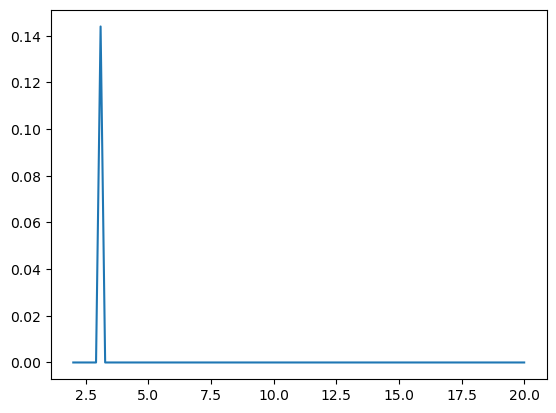

In [4]:
omega_true = 0.1
time_total = 4
t, signal = make_dummy_signal(time_total=time_total, n_timesteps=10000, omega=omega_true, noise_ratio=0.1, signal_type="sin")
uncerts = np.ones_like(signal) * 0.1

omega_min = 2
omega_max = 20
max_spacing = 1/(2*np.pi * time_total) #* Largest space between omega values to ensure no peaks are missed
num_omega = 100#math.ceil((omega_max - omega_min) / max_spacing)
# print(f"Sampling {num_omega} omega values between {omega_min} and {omega_max}")
Omega = np.linspace(omega_min, omega_max, num_omega)

Phi = np.linspace(0, 2*np.pi, 100)

M = np.arange(2, 13)

log_P_D = calculate_logprob(t, signal, uncerts, Omega, Phi, M, r_min=0, r_max=1)
P_D_marginalized, log_offset = marginalize_Phi_M(log_P_D, Omega, Phi, M, omega_min, omega_max)
plt.plot(Omega, P_D_marginalized)
plt.show()

In [ ]:
log_odds_ratio(log_P_D, log_P_constant(t, signal, uncerts, A_min=0, A_max=1), Omega, Phi, M, omega_min, omega_max)

339.3615097622022

In [6]:
# omega = 1.1
# phi = 0.0
# m = 5
# plt.hist(((t * omega + phi) / (2 * np.pi))%1, bins=100)

# def bin_times(times, omega, phi, m):
#     return np.floor((m+1) * ((times * omega + phi) % (2 * np.pi)) / (2 * np.pi)).astype(int)
# bins = bin_times(t, 1.0, 0.0, 5)
# print(np.unique(bins, return_counts=True))

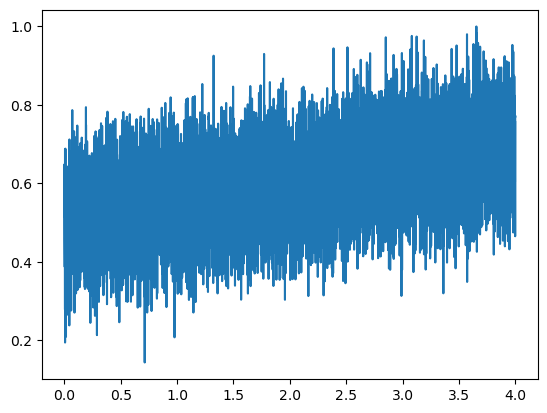

In [7]:
plt.plot(t, signal)

In [8]:
log_P_D.shape
P_D_over_M = simpson(P_D, x=Phi, axis=-1)


NameError: name 'P_D' is not defined